# Week 3 - Day 1: Supervised Learning & Train/Test Split

This notebook applies the fundamentals of supervised learning: inspecting a labeled dataset, identifying its inputs (features) and output (target), and preparing the data for honest model evaluation. Using the **Breast Cancer Wisconsin** dataset, we perform a binary classification framing, split the data into training and test sets (80/20), and verify the split — while establishing why the test portion must remain unseen during training to avoid data leakage.

## 1. Imports

We import the core libraries needed for data handling, dataset loading, and splitting the data into training and test sets.

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

## 2. Load the Dataset

We use the **Breast Cancer Wisconsin** dataset, built into Scikit-learn. It contains measurements computed from digitized images of breast mass cell nuclei, with each sample labeled as malignant or benign.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Problem Framing

This is a **binary classification** problem: given a set of measured characteristics of a cell nucleus, we want to predict whether it is **malignant** or **benign**.

This differs from a regression problem, where the target would be a continuous number (e.g., predicting a price or a measurement). Here, the target is a discrete category with exactly two possible values, which places this task firmly on the classification side of supervised learning.

## 4. Initial Data Inspection

Before separating features from the target, we take a quick look at the dataset's structure: its size, column types, and whether any values are missing. This step does not modify the data — it only confirms what we are working with.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (569, 31)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error    

In [4]:
df.isnull().sum().sum()

np.int64(0)

## 5. Features and Target (X, y)

We now separate the dataset into **features (X)** — the measurements the model learns from — and **target (y)** — the label we want to predict (malignant or benign).

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


## 6. Target Distribution

Before splitting the data, we check how balanced the two classes are. This matters because an imbalanced target can make a random split unrepresentative, and it directly motivates the stratification choice in the next step.

In [6]:
import matplotlib.pyplot as plt

y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

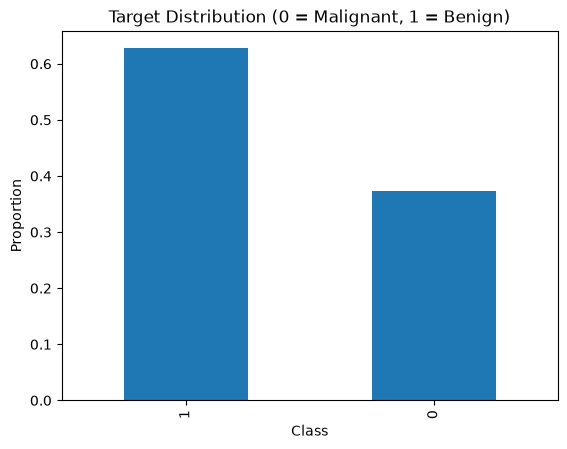

In [7]:
y.value_counts(normalize=True).plot(kind="bar")
plt.title("Target Distribution (0 = Malignant, 1 = Benign)")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.show()

## 7. Train/Test Split

We split the data into an 80% training set and a 20% test set. Since the target classes are not perfectly balanced (as seen above), we use `stratify=y` to ensure both sets preserve the same class proportions as the original dataset. A fixed `random_state` makes the split reproducible.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 8. Split Validation

We confirm that the split behaved as expected: the shapes are consistent with an 80/20 split, no samples were lost or duplicated, and the class proportions were preserved in both sets.

In [9]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [10]:
# Sanity check: no samples lost or duplicated during the split
assert len(X_train) + len(X_test) == len(X)
assert len(y_train) + len(y_test) == len(y)

print("Total samples preserved:", len(X_train) + len(X_test) == len(X))

Total samples preserved: True


In [11]:
# Sanity check: class proportions preserved after stratified split
print("Train proportions:\n", y_train.value_counts(normalize=True))
print("\nTest proportions:\n", y_test.value_counts(normalize=True))

Train proportions:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test proportions:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## 9. Why the Test Set Must Stay Unseen

The purpose of the test set is to estimate how the model will perform on new, real-world data it has never encountered. If the test set influences training in any way — whether the model is fit on it directly, or decisions about preprocessing and features are made by peeking at it — the evaluation stops being honest. The model may appear to perform very well simply because it has already "seen the answers," a problem known as **data leakage**.

This is why the split happens early, before any modeling: `X_test` and `y_test` are set aside now and will not be touched again until the final evaluation step. A model that only performs well on data it was trained on has not actually learned a generalizable pattern — it has memorized. Keeping the test set unseen is what allows a performance metric to genuinely reflect how the model would behave in production.

## 10. Key Takeaways

- **Supervised learning** trains a model on labeled examples, where the correct answer (target) is known during training.
- This is a **binary classification** problem: the target is a category (malignant/benign), not a continuous number — the defining difference from regression.
- **Features (X)** are the inputs the model learns from; **target (y)** is what it predicts.
- The dataset's classes were **not perfectly balanced**, which justified using `stratify=y` to preserve class proportions in both the training and test sets.
- The **train/test split** was performed once, early, with a fixed `random_state` for reproducibility.
- Sanity checks confirmed the split preserved all samples and the intended class balance.
- The **test set must remain unseen during training** — this is what makes the final evaluation an honest estimate of real-world performance, not a memorized result.